In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

### Rivelatore a Gas

Una particella carica di alta energia che attraversa un materiale può ionizzare alcuni degli atomi che incontra lungo il tragitto, lasciando una scia di ioni ed elettroni liberi.

Se il materiale è immerso in un campo elettrico, cariche positive e negative tendono a migrare in direzioni opposte senza ricombinarsi, creando così una corrente elettrica potenzialmente rivelabile.

Per questo esercizio prenderemo un rivelatore a gas usato per tracciare le particelle cariche come le **MultiWire Proportional Chambers (MWPC)**.

#### Campo elettrico in un MWPC

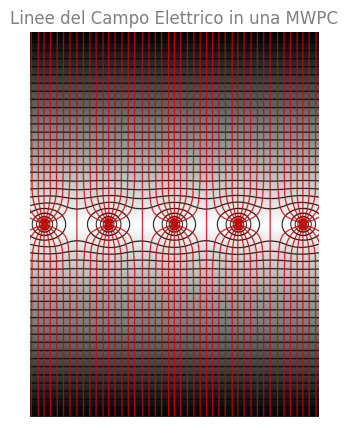

In [34]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(6,5))
ax.imshow(np.asarray(Image.open('/home/nicola_polito/MCF/E10/MWPC/MWPC_electric_field.svg.png')))
ax.set_title('Linee del Campo Elettrico in una MWPC', color='grey')
ax.axis('off')
plt.show()

A sufficiente distanza dagli anodi il campo è approssimativamente costante come quello di un condensatore piano a facce parallele:
$$ E = \frac{ | \sigma|}{\epsilon_m} \quad (d^2 \ll S)$$

$ \rightarrow$ la distanza tra le armature è molto minore delle loro dimensioni.

$ \sigma$ è la densità superficiale di carica su ciascuna delle due armature e $ \epsilon_m$ è la costante dielettrica del mezzo interposto tra le due armature.

In prossimità degli anodi il campo generato dal singolo filo diventa molto più intenso di quello generato dagli altri ed è approssimabile mediante un campo radiale.

$$ E = \frac{k*Q}{d^2}$$

#### Camera Proporzionale a Multifili

Una camera **MWPC** è un rivelatore di particelle, ideato nel 1968 al CERN, in grado di misurare la traiettoria di una particella che interagisce con il gas contenuto nella camera.

Il rivelatore è formato da centinaia di fili allineati, mantenuti ad alta tensione positiva, tra due piani metallici mantenuti al potenziale di massa, paralleli ed equidistanti dal piano dei fili.

I fili funzionano da anodi (polo positivo), mentre i piani da catodi (polo negativo). L'intuizione di base avuta da Charpak fu che ogni filo funzionasse come un contatore proporzionale.

Il Principio di Funzionamento di una MWPC può essere riassunto nei seguenti punti:
- Ionizzazone primaria e migrazione;
- Ionizzazione secondaria;
- Moltiplicazione a valanga;
- Rilevazione del segnale.

esplicati al seguente link:
https://it.wikipedia.org/wiki/Camera_proporzionale_a_multifili

### Descrizione Fenomeno

1. Una particella carica attraversa una **MWPC** rilasciando $n$ coppie ione-elettrone;
    - il valore di $n$ è soggetto a fluttuazioni poissoniane tra evento ed evento;
2. Le cariche iniziano a diffondersi grazie all'agitazione termica del gas;
3. Gli elettroni vengono spinti dal campo elettrico verso i fili;
4. In prossimità dei fili, il campo elettrico è così intenso che gli elettroni guadagnano abbastanza energia fra un urto e il successivo per ionizzare altri atomi, generando una reazione di moltiplicazione di carica;
5. La migrazione degli ioni generati dalla moltiplicazione in prossimità dei fili viene rivelata sotto forma di segnale elettrico;
6. Nelle condizioni di operazione delle MWPC il segnale rivelato è proporzionale al numero di coppie elettrone-ione iniziale n nella ionizzazione primaria.

####  Descrizione Geometria **MWPC**

1. La camera contenete il gas ha uno spessore di 1 cm;
2. I fili sono equidistanti dalle pareti della camera;
3. Il campo elettrico fra una parete e i fili può essere considerato uniforme;
4. Il campo è sempre diretto dai fili verso le pareti;
5. Si può assumere che lo spessore dell'area di camera attorno ai fili in cui il campo elettrico non è uniforme sia trascurabile.

### Implementazione MWPC

##### Implementazione geometria **MWPC**

In [35]:
#Implementazione MWPC

class MWPC:
    '''
    Classe che implementa la geometria di una MWPC

    s      : spessore della camera (distanza tra i due piani catodici)
    l      : dimensione longitudinale della camera (parallela ai fili)
    n_wires: numero di fili anodici
    d_sw   : distanza tra fili e piani catodici
    d_ww   : distanza trasversale tra i fili
    ef     : campo elettrico all'interno della camera
    '''

    def __init__(self):
        self.s=1 #cm
        self.l=2 #cm
        self.n_wires= 5
        self.d_sw=0.5 #cm
        self.d_ww=0.3 #cm
        self.ef= self.mwpc_ef()

    def mwpc_set(self, settings):
        self.s= settings[0]
        self.n_wires=settings[1]
        self.d_sw=settings[2]
        self.d_ww=settings[3]
        self.pe=settings[4]
    
    def mwpc_ef(self):
        yc=np.random.random(1000) #campo nella direzione trasversale ai fili
        xc=np.random.uniform(low=0, high=2, size=1000)
        e_f=np.array([xc,yc])
        return e_f
    
    def r_wire(self):
        xw=np.arange(0.3, 2 ,0.3)
        yw=self.d_sw
        t=np.array([.0,.0])
        rw=np.array([t for x in range(len(xw))])
        for i in range(len(xw)):
            rw[i]=np.array([xw[i],yw])
        return rw

#### Simulazione generazione primaria

In [36]:
#implementazione generazione coppia

class mwpc_genEI():
    """
    Classe che simula la generazione di coppie elettrone-ione in una mwpc

    np   : numero atteso di coppie elettrone-ione generate dalla distribuzione di poisson
    n_ei : numero di coppie elettrone-ione primarie, per evento
    p_ei : posizione coppie elettrone-ione primarie generate
    """
    
    def __init__(self):
        self.n_ei=0
        self.p_ei=np.empty(0)
        self.np = 5

    def ei_pair(self, mwpc):
        """
        ei_pair(): funzione che simula la generazione casuale di coppie elettrone-ione all'interno della camera:
            - il numero di coppie è regolato dalla distribuzione di poisson
            - la posizione delle coppie ha distribuzione uniforme lungo lo spessore della camera

        return p_ei, n_ei : posizione delle coppie generate, numero di coppie generate (per evento)
        """
        self.n_ei=np.random.poisson(self.np)
        t=np.array([0.0, 0.0])
        self.p_ei=np.array([t for x in range(self.n_ei)])
        for i in range(self.n_ei):
            y_ei=np.random.uniform(low=0, high=mwpc.s)
            x_ei=np.random.uniform(low=0, high=2)
            self.p_ei[i]=np.array([x_ei, y_ei])

    def __repr__(self):
        return ' Numero coppie elettrone-ione generate ionizzazione primaria: {:d} \
                \n Posizione coppie elettrone-ione generate ionizzazione primaria: \n {:} \n'.format(self.n_ei, self.p_ei)
    
    def __str__(self):
        return ' Numero coppie elettrone-ione generate ionizzazione primaria: {:d} \
                \n Posizione coppie elettrone-ione generate ionizzazione primaria: \n {:} \n'.format(self.n_ei, self.p_ei)

In [37]:
#simulazione generazione coppia
CP1=MWPC()
r=CP1.r_wire()
print('Posizione fili: \n',r)
pair1=mwpc_genEI()
pair1.ei_pair(CP1)

pair1

Posizione fili: 
 [[0.3 0.5]
 [0.6 0.5]
 [0.9 0.5]
 [1.2 0.5]
 [1.5 0.5]
 [1.8 0.5]]


 Numero coppie elettrone-ione generate ionizzazione primaria: 4                 
 Posizione coppie elettrone-ione generate ionizzazione primaria: 
 [[1.72115819 0.77504849]
 [0.59260294 0.82053269]
 [0.62600351 0.68355081]
 [1.01620374 0.3149661 ]] 

#### Simulazione Evento

In [38]:
#implementazione evento

class mwpc_event():
    """
    Classe che implementa la diffusione di una coppia e-i di generazione primaria in una mwpc
        params:
            su      : passo della diffusione per agitazione termica (cm)
            sf      : passo della diffusione per effetto del campo elettrico (cm)
            nr      : numero atteso di elettroni riassorbiti (1/nr --> probabilità di riassorbimento)
            tc      : tempo medio fra due urti durante la diffusione

            near_wire: anodo più vicino
            r_ei     : spostamento degli elettroni (cm)
            n_passi  : numero di passi della diffusione
            riv      : indice di rilevamento della particella carica
            td       : tempo di deriva degli elettroni

        set{params : val1}, default : val1
            parametri del processo
    """

    def __init__(self):
        self.near_wire=np.array([0,0])
        self.r_ei=np.empty(0)
        self.n_passi=0
        self.riv = True
        self.td=0

        self.params=('su', 'sf', 'nr', 'tc')
        self.val1= np.array([1e-5, 10e-5, 1e7, 1e-12]) #1e-7
        self.val2= np.array([1e-4, 5e-5, 1e4, 1e-12]) #5e-5
        self.set={ self.params[i]: j for i,j in zip(range(len(self.val1)), self.val1)}

    def set_p(self):
        print('SET 1: \n----- \n')
        for l,k in zip(self.params, self.val1):
            print(l, '=', k, '\n')
        print('SET2: \n----- \n')
        for l,k in zip(self.params, self.val2):
            print(l, '=', k, '\n')
        while(True):
            select=input(' Select setting:')
            if(select == 'SET 1'):
                break
            if(select == 'SET 2'):
                self.set={self.params[i]: j for i,j in zip(range(len(self.val2)),self.val2)}
                break

    def ei_diffusion(self, mwpc, pstart):
        '''
        ei_diffusion(pstart, step_t, step_e, rc): Simulazione del moto di diffusione delle coppie elettrone-ione: 
        - gli elettroni migrano verso il filo più vicino
        - una volta rilevato l'anodo più vicino, la diffusione avviene solo lungo la direzione trasversale ai fili (direzione del campo elettrico)
    
        mwpc  : rivelatore in cui avviene la diffusione
        pstart: posizione di generazione della coppia e-i

        return r_ei, n_passi: vettore che tiene traccia dello spostamento e numero di passi degli elettroni
        '''
    
        #condizioni iniziali
        self.r_ei=np.array(pstart[1])
        y_ei=pstart[1]
        e_step=self.set['sf']

        #rilevazione dell'anodo più vicino
        r=mwpc.r_wire()
        self.near_wire=r[0]
        m_wire=np.linalg.norm(r[0]-pstart)
        for p in r:
            term=np.linalg.norm(p-pstart)
            if(term < m_wire):
                m_wire=term
                self.near_wire=p
    
        #implementazione processo di diffusione per una coppia e-i
        #se la distanza dell'elettrone dal filo lungo la componente del campo è inferiore a 0.1 mm, si considera l'elettrone come rivelato con successo
        while(np.abs(y_ei - self.near_wire[1])>=0.1): 
            rc= np.random.poisson(1/self.set['nr']) #probabilità di riassorbimento
            #se l'elettrone è stato riassorbito o non ha raggiunto un piano catodico, la coppia non viene rivelata
            if(rc != 0 or y_ei>= mwpc.s or y_ei <=0):
                self.riv=False
                break

            y_ei= y_ei + self.set['su'] + e_step
            self.n_passi +=1
            self.r_ei=np.append(self.r_ei, y_ei)
            #print(t)
        if(self.riv == True):  
            self.r_ei=np.append(self.r_ei, self.near_wire[1])

    def derive_time(self):
        self.td=self.n_passi*self.set['tc']
    
    def __repr__(self): 
        return' Rivelato: {:} \n Anodo più vicino: {:} ' \
        '\n Numero Passi: {:d}  \n tempo di deriva per l\'evento: {:} secondi'.format(self.riv, self.near_wire, self.n_passi, self.td)
    
    def __str__(self): 
        return' Rivelato: {:} \n Anodo più vicino: {:} ' \
        '\n Numero Passi: {:d}  \n tempo di deriva per l\'evento: {:} secondi'.format(self.riv, self.near_wire, self.n_passi, self.td)
            

In [39]:
#simulazione evento
sim1=mwpc_event()
sim1.ei_diffusion(CP1, pair1.p_ei[0])
sim1.derive_time()

#print(sim1.r_ei)
sim1

 Rivelato: False 
 Anodo più vicino: [1.8 0.5] 
 Numero Passi: 2046  
 tempo di deriva per l'evento: 2.0459999999999998e-09 secondi

#### Simulazione Diffusione Elettroni

In [ ]:
#implementazione diffusione degli elettroni

class mwpc_diffusion():
    """
    Classe che implementa la diffusione di un certo numero di elettroni in una mwpc

    nei_pair : numero di coppie elettrone-ione generate
    nei_riv  : numero di elettroni rivelati
    n_step   : numero di passi per ogni elettrone rivelato
    nei_td   : tempi di deriva per ogni elettrone rivelato
    nei_p    : posizione iniziale delle coppie di ionizzazione primaria
    y_ei     : spostamento di ciascun elettrone
    """

    def __init__(self):
        self.nei_riv =0
        self.nei_pair=0
        self.nei_td =np.empty(0)
        self.n_step=np.empty(0)
        
        #coppie e-i generate e posizione
        self.pair2=mwpc_genEI()
        self.pair2.ei_pair(CP1)
        self.nei_p=self.pair2.p_ei
        
        #Evento
        self.t= mwpc_event()

        #Array contenente i singoli eventi
        self.esp = np.empty(0)
    
    #Set Evento
    def setting1(self):
        self.t.set_p()
    
    def setting2(self, params):
        if(params=="SET 2"):
            self.t.set={self.t.params[i]: j for i,j in zip(range(len(self.t.val2)),self.t.val2)}

    def events(self):
        print(' Il processo di diffusione ha registrato {:d} eventi: \n'.format(self.nei_riv))
        print(self.pair2)
        for i,k in zip(range(len(self.esp)), self.esp):
            print( " Evento {:}: \n ------ \n".format(i+1))
            print(k, "\n")

    #PROCESSO DI DIFFUSIONE    
    def diff_process(self):    
        for i,k in zip( range(len(self.pair2.p_ei)), self.pair2.p_ei):
            self.t= mwpc_event()
            y_ei=np.empty(0)
            self.esp=np.append(self.esp, self.t)
            self.t.ei_diffusion(CP1,k)
            y_ei = np.append(y_ei, self.esp[i].r_ei)

            self.n_step= np.append(self.n_step, self.esp[i].n_passi)

            self.esp[i].derive_time()
            self.nei_td=np.append(self.nei_td, self.esp[i].td)
            self.nei_pair=self.pair2.n_ei

            if self.esp[i].riv == True:
                self.nei_riv +=1

In [41]:
#simulazione diffusione degli elettroni

SIM1=mwpc_diffusion()
SIM1.setting1()
SIM1.diff_process()
SIM1.events()

SET 1: 
----- 

su = 1e-05 

sf = 0.0001 

nr = 10000000.0 

tc = 1e-12 

SET2: 
----- 

su = 0.0001 

sf = 5e-05 

nr = 10000.0 

tc = 1e-12 

 Il processo di diffusione ha registrato 1 eventi: 

 Numero coppie elettrone-ione generate ionizzazione primaria: 3                 
 Posizione coppie elettrone-ione generate ionizzazione primaria: 
 [[1.16207416 0.15958292]
 [0.77180536 0.94658926]
 [0.7064506  0.35689417]] 

 Evento 1: 
 ------ 

 Rivelato: False 
 Anodo più vicino: [0.6 0.5] 
 Numero Passi: 2248  
 tempo di deriva per l'evento: 2.248e-09 secondi 

 Evento 2: 
 ------ 

 Rivelato: False 
 Anodo più vicino: [0.6 0.5] 
 Numero Passi: 2248  
 tempo di deriva per l'evento: 2.248e-09 secondi 

 Evento 3: 
 ------ 

 Rivelato: False 
 Anodo più vicino: [0.6 0.5] 
 Numero Passi: 2248  
 tempo di deriva per l'evento: 2.248e-09 secondi 



##### Distribuzioni

In [42]:
class esperimento():

    def __init__(self):
        self.coppie_ei=np.empty(0)
        self.ei_rilevate=np.empty(0)
        self.riv_gen=np.empty(0)
        self.t_deriva=np.empty(0)
        self.tmin_deriva=np.empty(0)
        self.tmean_deriva=np.empty(0)

        self.set="SET 1"
        self.params=('su', 'sf', 'nr', 'tc')
        self.v1= np.array([1e-5, 10e-5, 1e7, 1e-12]) #1e-7
        self.v2= np.array([1e-4, 5e-5, 1e4, 1e-12]) #5e-5

    def setting(self):
        print('SET 1: \n----- \n')
        for l,k in zip(self.params, self.v1):
            print(l, '=', k, '\n')
        print('SET2: \n----- \n')
        for l,k in zip(self.params, self.v2):
            print(l, '=', k, '\n')
        while(True):
            select=input(' Select setting:')
            if(select == 'SET 1'):
                break
            if(select == 'SET 2'):
                self.set="SET 2"
                break
        
    def sim(self, n):
        for l, k in zip (range(n), tqdm(range(n), desc="Simulazione in corso...")):
            SIM=mwpc_diffusion()
            SIM.setting2(self.set)
            SIM.diff_process()
            self.coppie_ei=np.append(self.coppie_ei, SIM.nei_pair)
            self.ei_rilevate=np.append(self.ei_rilevate, SIM.nei_riv)
            if(SIM.nei_td.size > 0):
                self.t_deriva=np.append(self.t_deriva, SIM.nei_td[-1])
            if(SIM.nei_td.size > 0):
                self.tmin_deriva=np.append(self.tmin_deriva, np.min(SIM.nei_td[-1]))
            if(SIM.nei_td.size > 0):
                self.tmean_deriva=np.append(self.tmean_deriva, np.mean(SIM.nei_td[-1]))
            if(self.coppie_ei[-1] > 0):
                self.riv_gen=np.append(self.riv_gen, (self.ei_rilevate[-1]/self.coppie_ei[-1]))

In [43]:
N=500
ESP1=esperimento()
ESP1.setting()
ESP1.sim(N)

coppie_gen=ESP1.coppie_ei
elettroni_riv=ESP1.ei_rilevate
time_deriva=ESP1.t_deriva
time_dmedio=ESP1.tmean_deriva
time_dminimo=ESP1.tmean_deriva

SET 1: 
----- 

su = 1e-05 

sf = 0.0001 

nr = 10000000.0 

tc = 1e-12 

SET2: 
----- 

su = 0.0001 

sf = 5e-05 

nr = 10000.0 

tc = 1e-12 



Simulazione in corso...: 100%|█████████▉| 499/500 [01:37<00:00,  5.14it/s]


In [44]:
print(len(elettroni_riv))
print(len(coppie_gen))
print(len(time_deriva))
print(len(time_dmedio))
print(len(time_dminimo))
print(len(ESP1.riv_gen))

500
500
497
497
497
497


In [45]:
# Calcolo Efficienza di Rivelazione
def efficienza_mwpc():
    ''' 
    Funzione che calcola l'efficienza del rivelatore a gas

    Restituisce:
    ------------
    eff_e : efficienza di rivelazione di un elettrone
    eff_p : efficienza di rivelazione di una particella carica al nanosecondo
    '''

    eff_e=np.nanmean(ESP1.riv_gen)
    eff_p=np.empty(0)
    for i in range(len(ESP1.riv_gen)):
        if(ESP1.t_deriva[i]>0):
            eff_p=np.append(eff_p, ESP1.riv_gen[i]/(ESP1.t_deriva[i]*1e9)) #particelle al nanosecondo

    return eff_e, np.mean(eff_p)

eff1, eff2=efficienza_mwpc()
print(eff1, ' ', eff2)

0.2429387513894556   0.24273032086301954


/tmp/ipykernel_1352/1988107394.py:20: RuntimeWarning: invalid value encountered in divide
  ax["C"].scatter(xx1, (elettroni_riv/coppie_gen), s=45, marker='o', edgecolor='steelblue', color='skyblue', alpha=0.8)


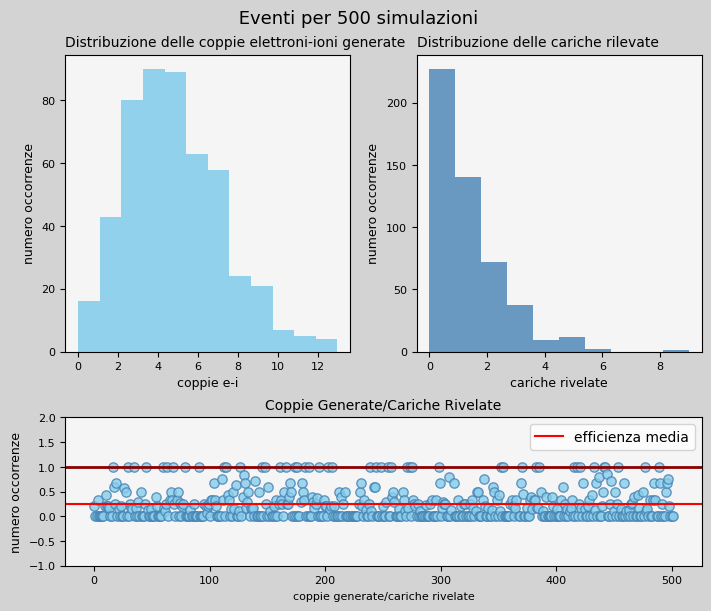

In [46]:
#Distribuzione particelle
xx1=np.linspace(0, 501, 500)
mosaic_layout=[["A", "B"],
               ["A", "B"],
               ["C", "C"]]
fig1, ax=plt.subplot_mosaic(mosaic_layout, figsize= (7, 6), layout='constrained', facecolor='lightgrey')
fig1.suptitle(' Eventi per {:d} simulazioni'.format(N), color='black', fontsize=13)

ax["A"].set_title('Distribuzione delle coppie elettroni-ioni generate', loc='left', color='black', fontsize=10)
ax["A"].hist(coppie_gen, bins=12, color= 'skyblue', alpha=0.9)
ax["A"].set_xlabel('coppie e-i', fontsize=9)
ax["A"].set_ylabel('numero occorrenze', fontsize=9)

ax["B"].set_title('Distribuzione delle cariche rilevate', loc='left', color='black', fontsize=10)
ax["B"].hist(elettroni_riv, bins=10, color='steelblue', alpha=0.8)
ax["B"].set_xlabel('cariche rivelate', fontsize=9)
ax["B"].set_ylabel('numero occorrenze', fontsize=9)

ax["C"].set_title('Coppie Generate/Cariche Rivelate', color='black', fontsize=10)
ax["C"].scatter(xx1, (elettroni_riv/coppie_gen), s=45, marker='o', edgecolor='steelblue', color='skyblue', alpha=0.8)
ax["C"].set_xlabel('coppie generate/cariche rivelate', fontsize=8)
ax["C"].set_ylabel('numero occorrenze', fontsize=9)
ax["C"].axhline(1, color='darkred', linewidth=2)
ax["C"].axhline(eff1, color='red', linewidth=1.5, label='efficienza media')
ax["C"].set_ylim(-1, 2)
ax["C"].legend()

for axs in fig1.get_axes():
    axs.set_facecolor('whitesmoke')
    axs.tick_params(axis='both', labelsize=8)

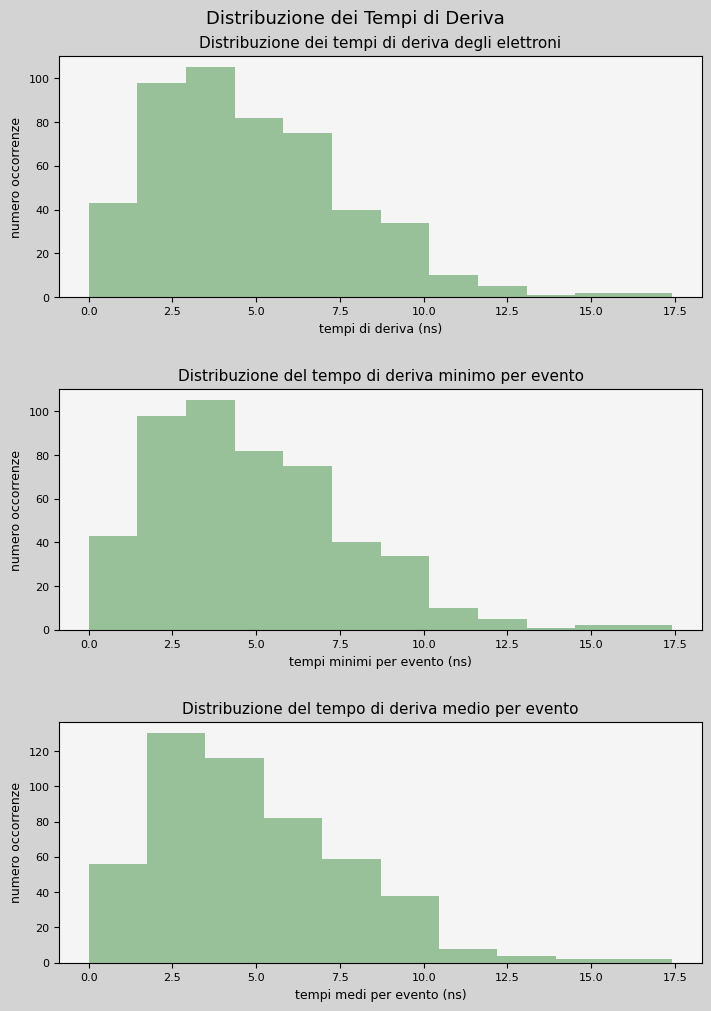

In [47]:
#Distribuzione Tempi di Deriva

conv=1e9
fig2= plt.figure(figsize=(7, 10), facecolor='lightgrey', layout='constrained')
gs = fig2.add_gridspec(3,1, hspace=0.1, wspace=0)
ax1,ax2, ax3= gs.subplots()
fig2.suptitle('Distribuzione dei Tempi di Deriva', fontsize=13)

ax1.set_title('Distribuzione dei tempi di deriva degli elettroni', color='black', fontsize=11)
ax1.hist(conv*time_deriva, bins=12, color= 'darkseagreen', alpha=0.9)
ax1.set_xlabel('tempi di deriva (ns)', fontsize=9)
ax1.set_ylabel('numero occorrenze', fontsize=9)

ax2.set_title('Distribuzione del tempo di deriva minimo per evento', color='black', fontsize=11)
ax2.hist(conv*time_dminimo, bins=12, color='darkseagreen', alpha=0.9)
ax2.set_xlabel('tempi minimi per evento (ns)', fontsize=9)
ax2.set_ylabel('numero occorrenze', fontsize=9)

ax3.set_title('Distribuzione del tempo di deriva medio per evento', color='black', fontsize=11)
ax3.hist(conv*time_dmedio, bins=10, color='darkseagreen', alpha=0.9)
ax3.set_xlabel('tempi medi per evento (ns)', fontsize=9)
ax3.set_ylabel('numero occorrenze', fontsize=9)

for axs in fig2.get_axes():
    axs.set_facecolor('whitesmoke')
    axs.tick_params(axis='both', labelsize=8)